In [1]:
import sys
import os 

project_root = "/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code"

sys.path.append(project_root)

In [2]:
from utils.analytics import eval_fit_methods
import networks
import estimator.stable_estimators as se
from scipy.stats import levy_stable
import matplotlib.pyplot as plt 
import seaborn as sns 
from utils import plots, optimreg
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import pandas as pd
import pickle
import numpy as np

<h1> Load CIFAR Dataset </h1>

In [3]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flach auf        3072
])

# Originaler vollständiger Trainingssatz
full_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# --- Train/Val Split definieren ---
train_size = int(0.8 * len(full_dataset))   # 80% Training
val_size   = len(full_dataset) - train_size # 20% Validation

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


<h1> Gaussian Network </h1>

In [40]:
optimreg.alpha_regularization(fc4_gaussian)

15.695889000000001

<h2> Pre Training </h2>

Inspect the Distribution of each layer for the gaussian initialized FC4 Network pre training 

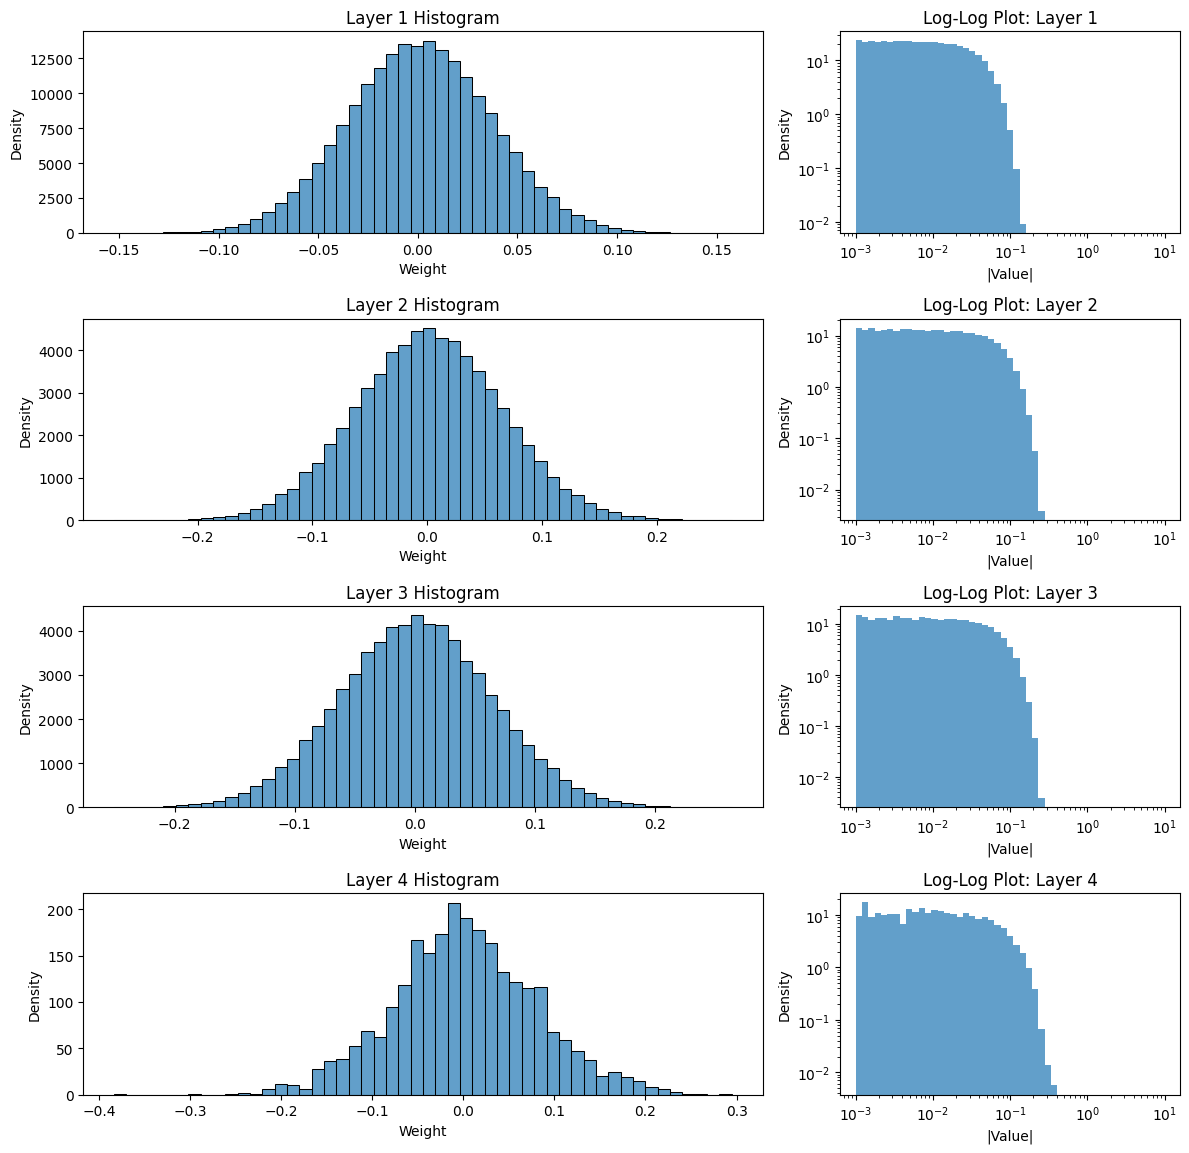

In [76]:
plots.layerwise_weight_dist(fc4_gaussian, log_log=True)

<h1> Training <h1>

<h2>Without regularizer<h2>

In [4]:
layer_sizes = [32*32*3] + [256]*9+ [10]

model = networks.FCNet(
    layer_sizes=layer_sizes,
    activation='relu',
    weight_init='gaussian'
)
model.to(device)

# Optimizer
optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

# Training
networks.train(
    model,
    train_loader,
    val_loader,
    optimizer,
    model_name="fc10_gaussian_none_sgd_cifar",
    epochs=200,
    lambda_reg=1e-2,
    logging=True,
    regularizer=None  
)

acc = networks.evaluate(model, test_loader)
print(acc)


Epoch 1/200 | Train Loss: 2.3004 | Train Acc: 15.02% | Val Loss: 2.2968 | Val Acc: 18.84%
Epoch 2/200 | Train Loss: 2.2928 | Train Acc: 17.86% | Val Loss: 2.2859 | Val Acc: 16.71%
Epoch 3/200 | Train Loss: 2.2741 | Train Acc: 17.11% | Val Loss: 2.2524 | Val Acc: 17.14%
Epoch 4/200 | Train Loss: 2.2065 | Train Acc: 17.80% | Val Loss: 2.1345 | Val Acc: 18.61%
Epoch 5/200 | Train Loss: 2.0889 | Train Acc: 19.04% | Val Loss: 2.0497 | Val Acc: 21.92%
Epoch 6/200 | Train Loss: 2.0385 | Train Acc: 22.29% | Val Loss: 2.0218 | Val Acc: 23.10%
Epoch 7/200 | Train Loss: 2.0080 | Train Acc: 24.57% | Val Loss: 1.9873 | Val Acc: 26.06%
Epoch 8/200 | Train Loss: 1.9678 | Train Acc: 26.32% | Val Loss: 1.9456 | Val Acc: 27.38%
Epoch 9/200 | Train Loss: 1.9261 | Train Acc: 28.26% | Val Loss: 1.8987 | Val Acc: 28.36%
Epoch 10/200 | Train Loss: 1.8861 | Train Acc: 29.87% | Val Loss: 1.8687 | Val Acc: 30.44%
Epoch 11/200 | Train Loss: 1.8575 | Train Acc: 31.60% | Val Loss: 1.8788 | Val Acc: 31.85%
Epoch 12

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 121/200 | Train Loss: 0.7000 | Train Acc: 74.47% | Val Loss: 1.8332 | Val Acc: 49.90%
Epoch 122/200 | Train Loss: 0.6939 | Train Acc: 74.40% | Val Loss: 1.8603 | Val Acc: 49.65%
Epoch 123/200 | Train Loss: 0.6834 | Train Acc: 74.63% | Val Loss: 1.9628 | Val Acc: 47.52%
Epoch 124/200 | Train Loss: 0.6795 | Train Acc: 74.80% | Val Loss: 1.8518 | Val Acc: 49.76%
Epoch 125/200 | Train Loss: 0.6714 | Train Acc: 75.28% | Val Loss: 1.8794 | Val Acc: 49.49%
Epoch 126/200 | Train Loss: 0.6615 | Train Acc: 75.47% | Val Loss: 1.8731 | Val Acc: 50.20%
Epoch 127/200 | Train Loss: 0.6561 | Train Acc: 76.03% | Val Loss: 1.8887 | Val Acc: 50.26%
Epoch 128/200 | Train Loss: 0.6445 | Train Acc: 76.23% | Val Loss: 1.9045 | Val Acc: 50.69%
Epoch 129/200 | Train Loss: 0.6442 | Train Acc: 76.10% | Val Loss: 1.9432 | Val Acc: 48.77%
Epoch 130/200 | Train Loss: 0.6412 | Train Acc: 76.38% | Val Loss: 1.9488 | Val Acc: 49.87%
Epoch 131/200 | Train Loss: 0.6322 | Train Acc: 76.67% | Val Loss: 1.8712 | Val 

In [5]:
accuracies = []

for i in range(10): 

    model = networks.FCNet(layer_sizes = [32*32*3] + [256]*9+ [10], activation='relu', weight_init='gaussian')
    model.to(device)

    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        val_loader, 
        optimizer,
        model_name="fc10_gaussian_none_sgd_cifar",
        epochs=200,
        lambda_reg=1e-2,
        logging=True, 
        run=i
    )

    acc = networks.evaluate(model, test_loader)
    accuracies.append(acc)

    print(acc)


print(accuracies)
print(np.mean(accuracies))
print(np.std(accuracies))

Epoch 1/200 | Train Loss: 2.2995 | Train Acc: 13.55% | Val Loss: 2.2963 | Val Acc: 16.73%
Epoch 2/200 | Train Loss: 2.2928 | Train Acc: 17.50% | Val Loss: 2.2866 | Val Acc: 18.49%
Epoch 3/200 | Train Loss: 2.2761 | Train Acc: 18.01% | Val Loss: 2.2577 | Val Acc: 18.09%
Epoch 4/200 | Train Loss: 2.2223 | Train Acc: 17.70% | Val Loss: 2.1635 | Val Acc: 18.05%
Epoch 5/200 | Train Loss: 2.1049 | Train Acc: 19.10% | Val Loss: 2.0579 | Val Acc: 21.90%
Epoch 6/200 | Train Loss: 2.0382 | Train Acc: 22.60% | Val Loss: 2.0161 | Val Acc: 24.60%
Epoch 7/200 | Train Loss: 1.9962 | Train Acc: 25.17% | Val Loss: 1.9699 | Val Acc: 26.16%
Epoch 8/200 | Train Loss: 1.9486 | Train Acc: 27.32% | Val Loss: 1.9269 | Val Acc: 27.85%
Epoch 9/200 | Train Loss: 1.9101 | Train Acc: 28.83% | Val Loss: 1.8957 | Val Acc: 29.83%
Epoch 10/200 | Train Loss: 1.8835 | Train Acc: 30.63% | Val Loss: 1.8633 | Val Acc: 31.85%
Epoch 11/200 | Train Loss: 1.8560 | Train Acc: 31.76% | Val Loss: 1.8466 | Val Acc: 31.91%
Epoch 12

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 112/200 | Train Loss: 0.7541 | Train Acc: 72.30% | Val Loss: 1.6561 | Val Acc: 51.48%
Epoch 113/200 | Train Loss: 0.7456 | Train Acc: 72.89% | Val Loss: 1.7174 | Val Acc: 50.38%
Epoch 114/200 | Train Loss: 0.7472 | Train Acc: 72.70% | Val Loss: 1.6409 | Val Acc: 51.82%
Epoch 115/200 | Train Loss: 0.7358 | Train Acc: 72.95% | Val Loss: 1.6802 | Val Acc: 51.63%
Epoch 116/200 | Train Loss: 0.7322 | Train Acc: 73.46% | Val Loss: 1.7284 | Val Acc: 49.74%
Epoch 117/200 | Train Loss: 0.7184 | Train Acc: 73.67% | Val Loss: 1.6721 | Val Acc: 51.74%
Epoch 118/200 | Train Loss: 0.7090 | Train Acc: 73.97% | Val Loss: 1.7727 | Val Acc: 50.50%
Epoch 119/200 | Train Loss: 0.7056 | Train Acc: 74.05% | Val Loss: 1.7375 | Val Acc: 50.67%
Epoch 120/200 | Train Loss: 0.6993 | Train Acc: 74.22% | Val Loss: 1.7798 | Val Acc: 50.00%
Epoch 121/200 | Train Loss: 0.6954 | Train Acc: 74.27% | Val Loss: 1.7797 | Val Acc: 50.57%
Epoch 122/200 | Train Loss: 0.6857 | Train Acc: 74.84% | Val Loss: 1.8288 | Val 

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 159/200 | Train Loss: 0.4315 | Train Acc: 84.39% | Val Loss: 2.4253 | Val Acc: 49.05%
Epoch 160/200 | Train Loss: 0.4207 | Train Acc: 84.66% | Val Loss: 2.5017 | Val Acc: 49.08%
Epoch 161/200 | Train Loss: 0.4229 | Train Acc: 84.43% | Val Loss: 2.3408 | Val Acc: 50.38%
Epoch 162/200 | Train Loss: 0.4250 | Train Acc: 84.47% | Val Loss: 2.3460 | Val Acc: 50.94%
Epoch 163/200 | Train Loss: 0.4152 | Train Acc: 84.82% | Val Loss: 2.3483 | Val Acc: 50.87%
Epoch 164/200 | Train Loss: 0.4120 | Train Acc: 84.80% | Val Loss: 2.5247 | Val Acc: 47.36%
Epoch 165/200 | Train Loss: 0.3982 | Train Acc: 85.56% | Val Loss: 2.3705 | Val Acc: 51.65%
Epoch 166/200 | Train Loss: 0.4015 | Train Acc: 85.37% | Val Loss: 2.4067 | Val Acc: 51.46%
Epoch 167/200 | Train Loss: 0.3905 | Train Acc: 85.70% | Val Loss: 2.4520 | Val Acc: 51.17%
Epoch 168/200 | Train Loss: 0.3869 | Train Acc: 85.96% | Val Loss: 2.4602 | Val Acc: 50.30%
Epoch 169/200 | Train Loss: 0.3721 | Train Acc: 86.38% | Val Loss: 2.4971 | Val 

...

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 107/200 | Train Loss: 0.7970 | Train Acc: 70.80% | Val Loss: 1.6535 | Val Acc: 50.84%
Epoch 108/200 | Train Loss: 0.7996 | Train Acc: 70.69% | Val Loss: 1.7908 | Val Acc: 48.39%
Epoch 109/200 | Train Loss: 0.7997 | Train Acc: 70.68% | Val Loss: 1.6637 | Val Acc: 50.46%
Epoch 110/200 | Train Loss: 0.7850 | Train Acc: 71.33% | Val Loss: 1.6858 | Val Acc: 50.12%
Epoch 111/200 | Train Loss: 0.7776 | Train Acc: 71.70% | Val Loss: 1.8018 | Val Acc: 48.77%
Epoch 112/200 | Train Loss: 0.7662 | Train Acc: 71.92% | Val Loss: 1.7078 | Val Acc: 50.24%
Epoch 113/200 | Train Loss: 0.7618 | Train Acc: 72.02% | Val Loss: 1.6820 | Val Acc: 51.22%
Epoch 114/200 | Train Loss: 0.7544 | Train Acc: 72.51% | Val Loss: 1.7439 | Val Acc: 49.72%
Epoch 115/200 | Train Loss: 0.7450 | Train Acc: 72.64% | Val Loss: 1.7028 | Val Acc: 51.19%
Epoch 116/200 | Train Loss: 0.7449 | Train Acc: 72.70% | Val Loss: 1.7544 | Val Acc: 50.50%
Epoch 117/200 | Train Loss: 0.7305 | Train Acc: 73.08% | Val Loss: 1.7014 | Val 

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 109/200 | Train Loss: 0.7835 | Train Acc: 71.22% | Val Loss: 1.6411 | Val Acc: 50.49%
Epoch 110/200 | Train Loss: 0.7841 | Train Acc: 71.15% | Val Loss: 1.6551 | Val Acc: 51.20%
Epoch 111/200 | Train Loss: 0.7725 | Train Acc: 71.51% | Val Loss: 1.6612 | Val Acc: 51.23%
Epoch 112/200 | Train Loss: 0.7582 | Train Acc: 72.35% | Val Loss: 1.6813 | Val Acc: 50.89%
Epoch 113/200 | Train Loss: 0.7567 | Train Acc: 72.33% | Val Loss: 1.7606 | Val Acc: 49.84%
Epoch 114/200 | Train Loss: 0.7528 | Train Acc: 72.19% | Val Loss: 1.8227 | Val Acc: 49.45%
Epoch 115/200 | Train Loss: 0.7447 | Train Acc: 72.61% | Val Loss: 1.6567 | Val Acc: 51.51%
Epoch 116/200 | Train Loss: 0.7352 | Train Acc: 72.96% | Val Loss: 1.7076 | Val Acc: 51.34%
Epoch 117/200 | Train Loss: 0.7243 | Train Acc: 73.30% | Val Loss: 1.8343 | Val Acc: 49.46%
Epoch 118/200 | Train Loss: 0.7213 | Train Acc: 73.61% | Val Loss: 1.6630 | Val Acc: 51.40%
Epoch 119/200 | Train Loss: 0.7113 | Train Acc: 73.85% | Val Loss: 1.7458 | Val 

KeyboardInterrupt: 

<h2> Hill Regularizer </h2>

In [ ]:
lambdas = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

results = []

for lbda in lambdas:

    model = networks.FCNet(layer_sizes=[32*32*3] + [256]*3+ [10], activation='relu', weight_init='gaussian')
    model.to(device)
    
    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        val_loader, 
        optimizer,
        epochs=10,
        lambda_reg=lbda,
        logging=False,
        regularizer="hill", 
   
    )
    
    acc = networks.evaluate(model, test_loader)
    
    results.append({"lambda": lbda, "accuracy": acc})

df_results = pd.DataFrame(results)
print(df_results)

import matplotlib.pyplot as plt
plt.semilogx(df_results['lambda'], df_results['accuracy'], marker='o')
plt.xlabel("Lambda")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Tuning: Lambda")
plt.grid(True)
plt.show()

Epoch 1/10 | Train Loss: 30.7891 | Train Acc: 24.88% | Val Loss: 1.9783 | Val Acc: 30.39%
Epoch 2/10 | Train Loss: 28.8983 | Train Acc: 30.10% | Val Loss: 2.0951 | Val Acc: 26.38%
Epoch 3/10 | Train Loss: 26.4988 | Train Acc: 30.52% | Val Loss: 1.9154 | Val Acc: 31.57%
Epoch 4/10 | Train Loss: 9.3267 | Train Acc: 34.95% | Val Loss: 1.8051 | Val Acc: 35.92%
Epoch 5/10 | Train Loss: 8.8899 | Train Acc: 37.84% | Val Loss: 1.7496 | Val Acc: 38.13%
Epoch 6/10 | Train Loss: 8.5750 | Train Acc: 39.69% | Val Loss: 1.7236 | Val Acc: 38.20%


In [ ]:
accuracies = []

for i in range(10):     
    model = networks.FCNet(layer_sizes=[32*32*3] + [256]*3+ [10], activation='relu', weight_init='gaussian')
    model.to(device)

    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        model_name="fc10_gaussian_hill_sgd",
        epochs=200,
        lambda_reg=5e-5,
        logging=True,
        regularizer="hill", 
        run = i
    )

    acc = networks.evaluate(model, test_loader)
    accuracies.append(acc)

    print(acc)


print(accuracies)
print(np.mean(accuracies))
print(np.std(accuracies))

Epoch 1/200, Loss: 6.7022, Accuracy: 10.13%
Epoch 2/200, Loss: 6.3712, Accuracy: 14.90%
Epoch 3/200, Loss: 6.1374, Accuracy: 17.45%
Epoch 4/200, Loss: 5.9405, Accuracy: 17.65%
Epoch 5/200, Loss: 5.7707, Accuracy: 18.38%
Epoch 6/200, Loss: 5.6211, Accuracy: 20.99%
Epoch 7/200, Loss: 5.4910, Accuracy: 22.37%
Epoch 8/200, Loss: 5.3729, Accuracy: 24.59%
Epoch 9/200, Loss: 5.2638, Accuracy: 26.52%
Epoch 10/200, Loss: 5.1679, Accuracy: 27.97%
Epoch 11/200, Loss: 5.0784, Accuracy: 28.99%
Epoch 12/200, Loss: 4.9955, Accuracy: 29.68%
Epoch 13/200, Loss: 4.9203, Accuracy: 30.53%
Epoch 14/200, Loss: 4.8498, Accuracy: 31.38%
Epoch 15/200, Loss: 4.7841, Accuracy: 31.99%
Epoch 16/200, Loss: 4.7215, Accuracy: 32.95%
Epoch 17/200, Loss: 4.6616, Accuracy: 33.60%
Epoch 18/200, Loss: 4.6048, Accuracy: 34.34%
Epoch 19/200, Loss: 4.5504, Accuracy: 35.05%
Epoch 20/200, Loss: 4.5013, Accuracy: 35.64%
Epoch 21/200, Loss: 4.4594, Accuracy: 35.96%
Epoch 22/200, Loss: 4.4268, Accuracy: 36.53%
Epoch 23/200, Loss:

<h2> Hill weighted <h2>

<h2> Parabolic Hill <h2>

<h2> Parabolic Multi <h2>

<h2> Lasso </h2>

Epoch 1/5, Loss: 0.3070, Accuracy: 93.28%
Epoch 2/5, Loss: 0.1699, Accuracy: 96.97%
Epoch 3/5, Loss: 0.1414, Accuracy: 97.89%
Epoch 4/5, Loss: 0.1225, Accuracy: 98.41%
Epoch 5/5, Loss: 0.1124, Accuracy: 98.63%
Test Accuracy: 97.65%
Epoch 1/5, Loss: 0.5302, Accuracy: 92.77%
Epoch 2/5, Loss: 0.3221, Accuracy: 96.61%
Epoch 3/5, Loss: 0.2566, Accuracy: 97.29%
Epoch 4/5, Loss: 0.2178, Accuracy: 97.68%
Epoch 5/5, Loss: 0.1912, Accuracy: 97.92%
Test Accuracy: 97.66%
Epoch 1/5, Loss: 0.6997, Accuracy: 92.16%
Epoch 2/5, Loss: 0.3971, Accuracy: 96.06%
Epoch 3/5, Loss: 0.3043, Accuracy: 96.89%
Epoch 4/5, Loss: 0.2588, Accuracy: 97.31%
Epoch 5/5, Loss: 0.2372, Accuracy: 97.47%
Test Accuracy: 97.03%
Epoch 1/5, Loss: 1.3181, Accuracy: 89.46%
Epoch 2/5, Loss: 0.6162, Accuracy: 93.45%
Epoch 3/5, Loss: 0.5084, Accuracy: 94.49%
Epoch 4/5, Loss: 0.4613, Accuracy: 94.91%
Epoch 5/5, Loss: 0.4334, Accuracy: 95.26%
Test Accuracy: 95.36%
Epoch 1/5, Loss: 1.6384, Accuracy: 87.66%
Epoch 2/5, Loss: 0.8029, Accur

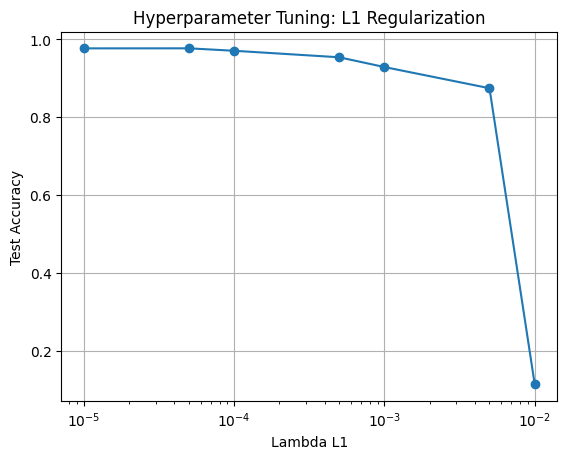

In [ ]:
lambdas = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

results = []

for lbda in lambdas:

    model = networks.FCNet(layer_sizes=[32*32*3] + [256]*3+ [10], activation='relu', weight_init='gaussian')
    model.to(device)
    
    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        val_loader, 
        optimizer,
        epochs=5,
        lambda_reg=lbda,
        logging=False,
        regularizer="lasso", 
   
    )
    
    acc = networks.evaluate(model, test_loader)
    
    results.append({"lambda": lbda, "accuracy": acc})

df_results = pd.DataFrame(results)
print(df_results)

import matplotlib.pyplot as plt
plt.semilogx(df_results['lambda'], df_results['accuracy'], marker='o')
plt.xlabel("Lambda")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Tuning: Lambda")
plt.grid(True)
plt.show()

In [ ]:
for i in range(10):     
    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)

    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        model_name="fc10_gaussian_lasso_sgd",
        epochs=200,
        lambda_reg=1e-5,
        logging=True,
        regularizer="lasso", 
        run = i
    )

    acc = networks.evaluate(model, test_loader)

    print(acc)

Epoch 1/200, Loss: 2.6244, Accuracy: 10.85%
Epoch 2/200, Loss: 2.6231, Accuracy: 11.56%
Epoch 3/200, Loss: 2.6218, Accuracy: 12.38%
Epoch 4/200, Loss: 2.6205, Accuracy: 14.38%
Epoch 5/200, Loss: 2.6193, Accuracy: 17.29%
Epoch 6/200, Loss: 2.6182, Accuracy: 19.59%
Epoch 7/200, Loss: 2.6171, Accuracy: 21.12%
Epoch 8/200, Loss: 2.6159, Accuracy: 22.31%
Epoch 9/200, Loss: 2.6147, Accuracy: 23.14%
Epoch 10/200, Loss: 2.6134, Accuracy: 23.93%
Epoch 11/200, Loss: 2.6119, Accuracy: 24.86%
Epoch 12/200, Loss: 2.6103, Accuracy: 25.54%
Epoch 13/200, Loss: 2.6086, Accuracy: 26.58%
Epoch 14/200, Loss: 2.6067, Accuracy: 27.53%
Epoch 15/200, Loss: 2.6045, Accuracy: 28.55%
Epoch 16/200, Loss: 2.6021, Accuracy: 29.42%
Epoch 17/200, Loss: 2.5993, Accuracy: 30.21%
Epoch 18/200, Loss: 2.5962, Accuracy: 31.39%
Epoch 19/200, Loss: 2.5926, Accuracy: 32.72%
Epoch 20/200, Loss: 2.5884, Accuracy: 34.45%
Epoch 21/200, Loss: 2.5836, Accuracy: 36.58%
Epoch 22/200, Loss: 2.5778, Accuracy: 38.66%
Epoch 23/200, Loss:

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 59/200, Loss: 0.7134, Accuracy: 88.58%
Epoch 60/200, Loss: 0.7066, Accuracy: 88.79%
Epoch 61/200, Loss: 0.6992, Accuracy: 89.05%
Epoch 62/200, Loss: 0.6925, Accuracy: 89.22%
Epoch 63/200, Loss: 0.6863, Accuracy: 89.39%
Epoch 64/200, Loss: 0.6811, Accuracy: 89.59%
Epoch 65/200, Loss: 0.6746, Accuracy: 89.76%
Epoch 66/200, Loss: 0.6690, Accuracy: 89.94%
Epoch 67/200, Loss: 0.6633, Accuracy: 90.02%
Epoch 68/200, Loss: 0.6579, Accuracy: 90.26%
Epoch 69/200, Loss: 0.6528, Accuracy: 90.46%
Epoch 70/200, Loss: 0.6484, Accuracy: 90.56%
Epoch 71/200, Loss: 0.6438, Accuracy: 90.62%
Epoch 72/200, Loss: 0.6384, Accuracy: 90.73%
Epoch 73/200, Loss: 0.6340, Accuracy: 90.91%
Epoch 74/200, Loss: 0.6294, Accuracy: 91.08%
Epoch 75/200, Loss: 0.6250, Accuracy: 91.18%
Epoch 76/200, Loss: 0.6213, Accuracy: 91.29%
Epoch 77/200, Loss: 0.6176, Accuracy: 91.40%
Epoch 78/200, Loss: 0.6125, Accuracy: 91.56%
Epoch 79/200, Loss: 0.6085, Accuracy: 91.70%
Epoch 80/200, Loss: 0.6045, Accuracy: 91.75%
Epoch 81/2

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 8/200, Loss: 2.6150, Accuracy: 24.57%
Epoch 9/200, Loss: 2.6136, Accuracy: 25.50%
Epoch 10/200, Loss: 2.6120, Accuracy: 26.25%
Epoch 11/200, Loss: 2.6102, Accuracy: 27.41%
Epoch 12/200, Loss: 2.6082, Accuracy: 28.50%
Epoch 13/200, Loss: 2.6061, Accuracy: 30.01%
Epoch 14/200, Loss: 2.6036, Accuracy: 31.14%
Epoch 15/200, Loss: 2.6008, Accuracy: 32.44%
Epoch 16/200, Loss: 2.5977, Accuracy: 33.80%
Epoch 17/200, Loss: 2.5941, Accuracy: 34.91%
Epoch 18/200, Loss: 2.5898, Accuracy: 36.11%
Epoch 19/200, Loss: 2.5848, Accuracy: 36.89%
Epoch 20/200, Loss: 2.5788, Accuracy: 37.30%
Epoch 21/200, Loss: 2.5717, Accuracy: 37.58%
Epoch 22/200, Loss: 2.5629, Accuracy: 36.96%
Epoch 23/200, Loss: 2.5518, Accuracy: 36.50%
Epoch 24/200, Loss: 2.5376, Accuracy: 35.49%
Epoch 25/200, Loss: 2.5191, Accuracy: 34.71%
Epoch 26/200, Loss: 2.4949, Accuracy: 34.17%
Epoch 27/200, Loss: 2.4633, Accuracy: 33.88%
Epoch 28/200, Loss: 2.4232, Accuracy: 34.31%
Epoch 29/200, Loss: 2.3733, Accuracy: 36.23%
Epoch 30/200

...

Epoch 105/200, Loss: 0.5328, Accuracy: 93.91%
Epoch 106/200, Loss: 0.5313, Accuracy: 93.92%
Epoch 107/200, Loss: 0.5288, Accuracy: 94.01%
Epoch 108/200, Loss: 0.5261, Accuracy: 94.12%
Epoch 109/200, Loss: 0.5240, Accuracy: 94.22%
Epoch 110/200, Loss: 0.5220, Accuracy: 94.25%


R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 111/200, Loss: 0.5195, Accuracy: 94.34%
Epoch 112/200, Loss: 0.5176, Accuracy: 94.36%
Epoch 113/200, Loss: 0.5158, Accuracy: 94.46%
Epoch 114/200, Loss: 0.5140, Accuracy: 94.49%
Epoch 115/200, Loss: 0.5117, Accuracy: 94.54%
Epoch 116/200, Loss: 0.5101, Accuracy: 94.62%
Epoch 117/200, Loss: 0.5082, Accuracy: 94.65%
Epoch 118/200, Loss: 0.5065, Accuracy: 94.73%
Epoch 119/200, Loss: 0.5049, Accuracy: 94.75%
Epoch 120/200, Loss: 0.5027, Accuracy: 94.82%
Epoch 121/200, Loss: 0.5015, Accuracy: 94.85%
Epoch 122/200, Loss: 0.4993, Accuracy: 94.94%
Epoch 123/200, Loss: 0.4975, Accuracy: 94.97%
Epoch 124/200, Loss: 0.4961, Accuracy: 95.01%
Epoch 125/200, Loss: 0.4945, Accuracy: 95.06%
Epoch 126/200, Loss: 0.4932, Accuracy: 95.10%
Epoch 127/200, Loss: 0.4920, Accuracy: 95.17%
Epoch 128/200, Loss: 0.4902, Accuracy: 95.18%
Epoch 129/200, Loss: 0.4890, Accuracy: 95.23%
Epoch 130/200, Loss: 0.4870, Accuracy: 95.27%
Epoch 131/200, Loss: 0.4855, Accuracy: 95.29%
Epoch 132/200, Loss: 0.4841, Accur

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 156/200, Loss: 0.4560, Accuracy: 96.16%
Epoch 157/200, Loss: 0.4548, Accuracy: 96.19%
Epoch 158/200, Loss: 0.4539, Accuracy: 96.19%
Epoch 159/200, Loss: 0.4535, Accuracy: 96.21%
Epoch 160/200, Loss: 0.4522, Accuracy: 96.22%
Epoch 161/200, Loss: 0.4511, Accuracy: 96.27%
Epoch 162/200, Loss: 0.4501, Accuracy: 96.28%
Epoch 163/200, Loss: 0.4492, Accuracy: 96.32%
Epoch 164/200, Loss: 0.4488, Accuracy: 96.30%
Epoch 165/200, Loss: 0.4477, Accuracy: 96.34%
Epoch 166/200, Loss: 0.4466, Accuracy: 96.41%
Epoch 167/200, Loss: 0.4459, Accuracy: 96.39%
Epoch 168/200, Loss: 0.4452, Accuracy: 96.41%
Epoch 169/200, Loss: 0.4446, Accuracy: 96.51%
Epoch 170/200, Loss: 0.4436, Accuracy: 96.46%
Epoch 171/200, Loss: 0.4427, Accuracy: 96.53%
Epoch 172/200, Loss: 0.4418, Accuracy: 96.50%
Epoch 173/200, Loss: 0.4410, Accuracy: 96.56%
Epoch 174/200, Loss: 0.4405, Accuracy: 96.58%
Epoch 175/200, Loss: 0.4399, Accuracy: 96.61%
Epoch 176/200, Loss: 0.4391, Accuracy: 96.58%
Epoch 177/200, Loss: 0.4380, Accur

<h2> Paper Implementations </h2>

In [ ]:
lambdas = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

results = []

for lbda in lambdas:

    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)
    
    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        epochs=10,
        lambda_reg=lbda,
        logging=False,
        regularizer="xiao", 
   
    )
    
    acc = networks.evaluate(model, test_loader)
    
    results.append({"lambda": lbda, "accuracy": acc})

df_results = pd.DataFrame(results)
print(df_results)

import matplotlib.pyplot as plt
plt.semilogx(df_results['lambda'], df_results['accuracy'], marker='o')
plt.xlabel("Lambda")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Tuning: Alpha Regularization")
plt.grid(True)
plt.show()

In [4]:
for i in range(1):     
    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)

    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        model_name="fc10_gaussian_decay_sgd",
        epochs=200,
        lambda_reg=1e-5,
        logging=True,
        regularizer="decay", 
        run = i
    )

    acc = networks.evaluate(model, test_loader)

    print(acc)

Epoch 1/200, Loss: 18.3796, Accuracy: 13.86%
Epoch 2/200, Loss: 8.2153, Accuracy: 11.24%
Epoch 3/200, Loss: 5.7718, Accuracy: 11.24%
Epoch 4/200, Loss: 4.6756, Accuracy: 11.24%
Epoch 5/200, Loss: 4.0714, Accuracy: 11.24%
Epoch 6/200, Loss: 3.6713, Accuracy: 11.24%
Epoch 7/200, Loss: 3.4131, Accuracy: 11.24%


KeyboardInterrupt: 